In [1]:
from google.colab import drive
drive.mount("/content/drive")

import os
current_path = "/content/drive/MyDrive/dl-techniques-01"
os.chdir(current_path)
print(os.getcwd())

Mounted at /content/drive
/content/drive/MyDrive/dl-techniques-01


In [2]:
import numpy as np
from pathlib import Path

import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras.preprocessing import image_dataset_from_directory

from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input

In [3]:
batch_size = 32
img_width = 224
img_height = 224

In [6]:
data_path = "./datasets/flowers"

train_ds = image_dataset_from_directory(
    data_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = image_dataset_from_directory(
    data_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 11200 files belonging to 7 classes.
Using 8960 files for training.
Found 11200 files belonging to 7 classes.
Using 2240 files for validation.


In [7]:
classes = train_ds.class_names

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)

base_model = VGG16(include_top=False, weights='imagenet', input_shape=(224, 224, 3))
base_model.trainable = False

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
data_agumentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomZoom(0.1),
    layers.RandomRotation(0.2)
])

model = tf.keras.Sequential([
    layers.Input(shape=(224, 224, 3)),
    data_agumentation,
    layers.Lambda(preprocess_input),
    base_model,

    layers.Conv2D(32, kernel_size=(3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPool2D(),
    layers.Dropout(0.3),

    layers.Conv2D(64, kernel_size=(3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.Dropout(0.3),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.35),

    layers.Dense(len(classes), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 7, 7, 32)       │       147,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 7, 7, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 3, 3, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 3, 3, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 3, 3, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 3, 3, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,955,815 (57.05 MB)

 Trainable params: 240,935 (941.15 KB)

 Non-trainable params: 14,714,880 (56.13 MB)

In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    patience=10,
    restore_best_weights=True
)

model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
280/280 ━━━━━━━━━━━━━━━━━━━━ 1751s 2s/step - accuracy: 0.7066 - loss: 0.8304 - val_accuracy: 0.8839 - val_loss: 0.3707
Epoch 2/100
280/280 ━━━━━━━━━━━━━━━━━━━━ 51s 183ms/step - accuracy: 0.8439 - loss: 0.4803 - val_accuracy: 0.8969 - val_loss: 0.3238
Epoch 3/100
280/280 ━━━━━━━━━━━━━━━━━━━━ 53s 189ms/step - accuracy: 0.8636 - loss: 0.4161 - val_accuracy: 0.9085 - val_loss: 0.2732
Epoch 4/100
280/280 ━━━━━━━━━━━━━━━━━━━━ 54s 195ms/step - accuracy: 0.8762 - loss: 0.3670 - val_accuracy: 0.9192 - val_loss: 0.2468
Epoch 5/100
280/280 ━━━━━━━━━━━━━━━━━━━━ 55s 198ms/step - accuracy: 0.8879 - loss: 0.3432 - val_accuracy: 0.9161 - val_loss: 0.2533
Epoch 6/100
280/280 ━━━━━━━━━━━━━━━━━━━━ 56s 199ms/step - accuracy: 0.8953 - loss: 0.3210 - val_accuracy: 0.9138 - val_loss: 0.2618
Epoch 7/100
280/280 ━━━━━━━━━━━━━━━━━━━━ 55s 198ms/step - accuracy: 0.8998 - loss: 0.2985 - val_accuracy: 0.9170 - val_loss: 0.2684
Epoch 8/100
280/280 ━━━━━━━━━━━━━━━━━━━━ 57s 202ms/step - accuracy: 0.9044 - 

In [ ]:
model.save("feature_extracted_cnn_accuracy_94.keras")

In [4]:
model = tf.keras.models.load_model("./feature_extracted_cnn_accuracy_94.keras", compile=False, custom_objects={'preprocess_input': preprocess_input})

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step
Predicted class: tulip
Confidence: 96.86%


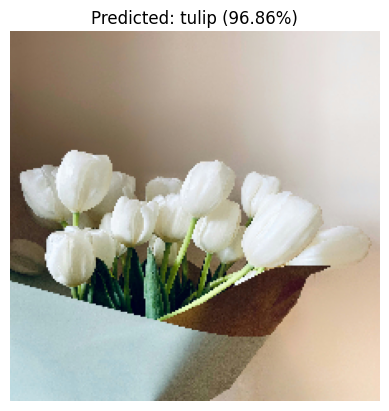

In [9]:
import matplotlib.pyplot as plt

classes = ['bellflower', 'daisy','dandelion', 'lotus', 'rose', 'sunflower', 'tulip']
image_path = './tulip.jpg'

# Load and preprocess the image
img = tf.keras.utils.load_img(image_path, target_size=(img_height, img_width))
img_array = tf.keras.utils.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) # Create a batch

# Preprocess the input for VGG16 (scaling, etc.)
processed_img = preprocess_input(img_array)

# Make a prediction
predictions = model.predict(processed_img)

# Get the predicted class index
predicted_class_index = np.argmax(predictions[0])
predicted_class_name = classes[predicted_class_index]
confidence = np.max(predictions[0]) * 100

print(f"Predicted class: {predicted_class_name}")
print(f"Confidence: {confidence:.2f}%")

# Display the image
plt.imshow(img)
plt.axis('off')
plt.title(f"Predicted: {predicted_class_name} ({confidence:.2f}%)")
plt.show()